In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC

In [3]:
bankdata = pd.read_csv("dataset\\bill_authentication.csv")

bankdata.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [5]:
from sklearn.model_selection import train_test_split

y = bankdata.pop("Class")
X = bankdata

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

print(X.shape)
print(y.shape)

print(X_train.shape)
print(X_test.shape)

(1372, 4)
(1372,)
(1097, 4)
(275, 4)


In [7]:
## Create model and train

mexercise = SVC(kernel='linear', C=1000)
mexercise.fit(X_train, y_train)  # Train the model

SVC(C=1000, kernel='linear')

In [9]:
y_pred = mexercise.predict(X_test)

In [11]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

clr = classification_report(y_test, y_pred)

print(clr)

[[147   4]
 [  1 123]]
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       151
           1       0.97      0.99      0.98       124

    accuracy                           0.98       275
   macro avg       0.98      0.98      0.98       275
weighted avg       0.98      0.98      0.98       275



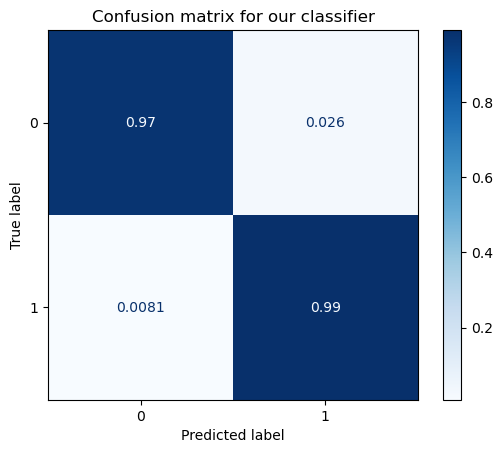

In [15]:
disp = ConfusionMatrixDisplay.from_estimator(mexercise, X_test, y_test, cmap=plt.cm.Blues, normalize='true')


plt.title('Confusion matrix for our classifier')
plt.show()